<a href="https://colab.research.google.com/github/chiragjotwani/Adaptive_Ensemble_Learning_for_Smart_Irrigation/blob/main/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
# BLOCK 1: Imports
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, StackingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

try:
    from xgboost import XGBClassifier
except ImportError:
    import sys
    !{sys.executable} -m pip install -q xgboost
    from xgboost import XGBClassifier

In [24]:
# BLOCK 2: Data Loading
if "df" not in globals():
    df = pd.read_csv("https://docs.google.com/spreadsheets/d/1YLYxCrtKZKWaa0Q1Hs466iH_81cG9ort/export?format=csv")

df = df.copy()
df.columns = df.columns.str.strip()
display(df.head())
print(f"Dataset shape: {df.shape}")

,timestamp,temperature,soil_moisture,soil_ph,water_tds,humidity,label
0,2025-08-27 9:57:25,34.607440,24.477109,6.856339,56.115680,43.341261,Needs Water + Too Low Nutrients in Water
1,2025-08-27 9:58:25,35.295893,21.098226,6.923694,526.382470,48.168213,Needs Water + Too Hot + Poor Water Quality
2,2025-08-27 9:59:25,33.575288,68.516594,5.559082,282.789400,58.614991,Soil Too Acidic
3,2025-08-27 10:00:25,39.892226,28.432351,6.143108,107.241196,53.308970,Needs Water + Too Hot
4,2025-08-27 10:01:25,38.510814,18.380766,7.116444,651.259549,86.323745,Needs Water + Too Hot + Poor Water Quality + H...


Dataset shape: (1000, 7)


In [25]:
# BLOCK 3: Data Preprocessing
feature_columns = ["temperature", "soil_moisture", "soil_ph", "water_tds", "humidity"]
target_column = "label"

missing_columns = [col for col in feature_columns + [target_column] if col not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

data = df[feature_columns + [target_column]].copy()
data[target_column] = data[target_column].astype(str).str.strip()
data = data.dropna(subset=[target_column]).reset_index(drop=True)

class_counts = data[target_column].value_counts()
rare_classes = class_counts[class_counts < 2].index.tolist()
if rare_classes:
    data.loc[data[target_column].isin(rare_classes), target_column] = "Other"
    if (data[target_column] == "Other").sum() < 2:
        data = data[data[target_column] != "Other"].copy()

class_counts = data[target_column].value_counts()
valid_labels = class_counts[class_counts >= 2].index
data = data[data[target_column].isin(valid_labels)].reset_index(drop=True)

if data[target_column].nunique() < 2:
    raise ValueError("At least two valid classes with >= 2 samples are required after rare-class handling.")

label_encoder = LabelEncoder()
data["label_encoded"] = label_encoder.fit_transform(data[target_column])

X = data[feature_columns].copy()
y = data["label_encoded"].copy()

stratify_target = y if y.value_counts().min() >= 2 else None

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=stratify_target
)

numeric_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler())
                ]
            ),
            feature_columns,
        )
    ],
    remainder="drop"
)

cv_folds = min(5, max(2, y_train.value_counts().min()))
cv_strategy = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Classes:", list(label_encoder.classes_))
display(data[target_column].value_counts().rename_axis("label").reset_index(name="count"))

Training shape: (800, 5)
Test shape: (200, 5)
Classes: ['Healthy', 'High Humidity', 'Low Humidity', 'Needs Water', 'Needs Water + High Humidity', 'Needs Water + Low Humidity', 'Needs Water + Poor Water Quality', 'Needs Water + Poor Water Quality + High Humidity', 'Needs Water + Poor Water Quality + Low Humidity', 'Needs Water + Soil Too Acidic', 'Needs Water + Soil Too Acidic + Low Humidity', 'Needs Water + Soil Too Acidic + Poor Water Quality', 'Needs Water + Soil Too Acidic + Poor Water Quality + High Humidity', 'Needs Water + Soil Too Acidic + Poor Water Quality + Low Humidity', 'Needs Water + Soil Too Acidic + Too Low Nutrients in Water', 'Needs Water + Soil Too Acidic + Too Low Nutrients in Water + High Humidity', 'Needs Water + Soil Too Alkaline', 'Needs Water + Soil Too Alkaline + High Humidity', 'Needs Water + Soil Too Alkaline + Low Humidity', 'Needs Water + Soil Too Alkaline + Poor Water Quality', 'Needs Water + Soil Too Alkaline + Poor Water Quality + High Humidity', 'Needs 

,label,count
0,Healthy,120
1,Needs Water,55
2,Poor Water Quality,50
3,Soil Too Acidic,37
4,Soil Too Alkaline,35
...,...,...
95,Soil Too Acidic + Too Low Nutrients in Water +...,2
96,Needs Water + Too Low Nutrients in Water + Hig...,2
97,Needs Water + Soil Too Acidic + Poor Water Qua...,2
98,Needs Water + Soil Too Acidic + Too Low Nutrie...,2


In [29]:
# BLOCK 4: Reusable Utilities (UPDATE THE make_xgb_pipeline FUNCTION)
def make_rf_pipeline():
    return Pipeline(
        steps=[
            ("preprocessor", ColumnTransformer(
                transformers=[
                    ("num", Pipeline([
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler())
                    ]), feature_columns)
                ],
                remainder="drop"
            )),
            (
                "model",
                RandomForestClassifier(
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                    class_weight="balanced_subsample"
                )
            )
        ]
    )


def make_xgb_pipeline():
    # Get number of classes from global y_train if available
    num_classes = len(np.unique(y_train)) if 'y_train' in globals() else 3

    return Pipeline(
        steps=[
            ("preprocessor", ColumnTransformer(
                transformers=[
                    ("num", Pipeline([
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler())
                    ]), feature_columns)
                ],
                remainder="drop"
            )),
            (
                "model",
                XGBClassifier(
                    objective="multi:softprob",
                    eval_metric="mlogloss",
                    random_state=RANDOM_STATE,
                    use_label_encoder=False,
                    n_estimators=200,
                    learning_rate=0.1,
                    max_depth=4,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    reg_lambda=1.0,
                    min_child_weight=1,
                    tree_method="hist",
                    verbosity=0,
                    num_class=num_classes  # Explicitly set number of classes
                )
            )
        ]
    )


def make_gb_pipeline():
    return Pipeline(
        steps=[
            ("preprocessor", ColumnTransformer(
                transformers=[
                    ("num", Pipeline([
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler())
                    ]), feature_columns)
                ],
                remainder="drop"
            )),
            ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
        ]
    )


def tune_model(name, pipeline, param_distributions, X_fit, y_fit, n_iter=12):
    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring="accuracy",
        n_jobs=-1,
        cv=cv_strategy,
        random_state=RANDOM_STATE,
        refit=True,
        verbose=0,
        error_score='raise'  # Changed to raise errors instead of returning nan
    )
    search.fit(X_fit, y_fit)
    print(f"{name} best CV accuracy: {search.best_score_:.4f}")
    print(f"{name} best params: {search.best_params_}")
    return search.best_estimator_, search.best_score_, search.best_params_


def evaluate_model(model_name, model, X_eval, y_eval, encoder):
    y_pred = model.predict(X_eval)
    acc = accuracy_score(y_eval, y_pred)
    decoded_true = encoder.inverse_transform(y_eval)
    decoded_pred = encoder.inverse_transform(y_pred)
    labels = encoder.classes_

    print(f"\n{model_name} Accuracy: {acc:.4f}")
    print(classification_report(decoded_true, decoded_pred, labels=labels, zero_division=0))

    cm = confusion_matrix(decoded_true, decoded_pred, labels=labels)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return {"model": model_name, "accuracy": acc, "y_pred": y_pred}


def plot_feature_importance(fitted_pipeline, model_name, top_n=None):
    model = fitted_pipeline.named_steps["model"]
    importances = pd.Series(model.feature_importances_, index=feature_columns).sort_values(ascending=False)
    if top_n is not None:
        importances = importances.head(top_n)

    plt.figure(figsize=(8, 5))
    sns.barplot(x=importances.values, y=importances.index, palette="viridis")
    plt.title(f"{model_name} Feature Importance")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

In [32]:
# BLOCK 5: Hyperparameter Tuning and Model Training (WORKING VERSION)
rf_pipeline = make_rf_pipeline()
gb_pipeline = make_gb_pipeline()

rf_param_dist = {
    "model__n_estimators": [200, 300, 400, 500, 700],
    "model__max_depth": [None, 5, 8, 12, 16, 20],
    "model__min_samples_split": [2, 4, 6, 8],
    "model__min_samples_leaf": [1, 2, 3, 4],
    "model__max_features": ["sqrt", "log2", None]
}

gb_param_dist = {
    "model__n_estimators": [100, 150, 200, 250, 300],
    "model__learning_rate": [0.03, 0.05, 0.08, 0.1, 0.15],
    "model__max_depth": [2, 3, 4, 5],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__min_samples_split": [2, 4, 6],
    "model__min_samples_leaf": [1, 2, 3]
}

num_classes = len(np.unique(y_train))
print(f"Number of classes: {num_classes}")
print(f"Class distribution in training: {pd.Series(y_train).value_counts().sort_index()}")

print("\nTuning Random Forest...")
best_rf_model, rf_cv_score, rf_best_params = tune_model("Random Forest", rf_pipeline, rf_param_dist, X_train, y_train)

print("\nTuning Gradient Boosting...")
best_gb_model, gb_cv_score, gb_best_params = tune_model("Gradient Boosting", gb_pipeline, gb_param_dist, X_train, y_train)

# SKIP XGBOOST - it doesn't work well with 100 imbalanced classes
print("\n" + "="*60)
print("SKIPPING XGBoost due to 100-class dataset limitations")
print("XGBoost requires continuous class labels in every CV fold")
print("With 100 imbalanced classes, some folds will miss classes")
print("="*60)

# Set dummy values for XGBoost (we won't use it)
best_xgb_model = None
xgb_cv_score = 0.0
xgb_best_params = {}

print("\nTraining completed!")
print(f"Random Forest CV: {rf_cv_score:.4f}")
print(f"Gradient Boosting CV: {gb_cv_score:.4f}")

Number of classes: 100
Class distribution in training: label_encoded
0     96
1     17
2     23
3     44
4      9
      ..
95     2
96     2
97     6
98    12
99     4
Name: count, Length: 100, dtype: int64

Tuning Random Forest...
Random Forest best CV accuracy: 0.8787
Random Forest best params: {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_features': 'log2', 'model__max_depth': 12}

Tuning Gradient Boosting...
Gradient Boosting best CV accuracy: 0.4788
Gradient Boosting best params: {'model__subsample': 0.9, 'model__n_estimators': 200, 'model__min_samples_split': 4, 'model__min_samples_leaf': 3, 'model__max_depth': 3, 'model__learning_rate': 0.03}

SKIPPING XGBoost due to 100-class dataset limitations
XGBoost requires continuous class labels in every CV fold
With 100 imbalanced classes, some folds will miss classes

Training completed!
Random Forest CV: 0.8787
Gradient Boosting CV: 0.4788


In [35]:
# BLOCK 6: IMPROVED Stacking Ensemble (FIXED)

print("\n" + "="*60)
print("ANALYZING MODEL PERFORMANCES")
print("="*60)
print(f"Random Forest CV: {rf_cv_score:.4f} ✓ EXCELLENT")
print(f"Gradient Boosting CV: {gb_cv_score:.4f} ✗ POOR")
print("\nGradient Boosting is performing poorly on this 100-class dataset.")
print("We'll create TWO ensembles for comparison:")
print("1. Stacking with only Random Forest (weighted)")
print("2. Multiple Random Forests with different configurations")
print("="*60)

# Option 1: Stacking with ONLY Random Forest (different configurations)
rf_config_1 = clone(best_rf_model.named_steps["model"])
rf_config_2 = RandomForestClassifier(
    n_estimators=500,
    max_depth=16,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=RANDOM_STATE + 1,
    n_jobs=-1,
    class_weight='balanced_subsample'
)
rf_config_3 = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=4,
    min_samples_leaf=1,
    max_features='log2',
    random_state=RANDOM_STATE + 2,
    n_jobs=-1,
    class_weight='balanced_subsample'
)

stacking_estimators_v1 = [
    ("rf_tuned", rf_config_1),
    ("rf_deep", rf_config_2),
    ("rf_wide", rf_config_3)
]

stacking_classifier_v1 = StackingClassifier(
    estimators=stacking_estimators_v1,
    final_estimator=LogisticRegression(max_iter=3000, random_state=RANDOM_STATE),
    stack_method="predict_proba",
    cv=cv_strategy,
    n_jobs=-1
)

stacking_pipeline_v1 = Pipeline([
    ("preprocessor", ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), feature_columns)
        ],
        remainder="drop"
    )),
    ("model", stacking_classifier_v1)
])

print("\nEvaluating Multi-RF Stacking Ensemble with CV...")
stacking_v1_cv_scores = cross_val_score(
    stacking_pipeline_v1,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=-1
)
stacking_v1_cv_score = stacking_v1_cv_scores.mean()

print(f"Training Multi-RF Stacking Ensemble...")
stacking_pipeline_v1.fit(X_train, y_train)

print(f"\nMulti-RF Stacking CV accuracy: {stacking_v1_cv_score:.4f}")
print(f"Multi-RF Stacking CV std: {stacking_v1_cv_scores.std():.4f}")

# Option 2: Voting Classifier (simpler alternative)
from sklearn.ensemble import VotingClassifier

voting_estimators = [
    ("rf_tuned", clone(best_rf_model.named_steps["model"])),
    ("rf_deep", rf_config_2),
    ("rf_wide", rf_config_3)
]

voting_classifier = VotingClassifier(
    estimators=voting_estimators,
    voting='soft',
    n_jobs=-1
)

voting_pipeline = Pipeline([
    ("preprocessor", ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), feature_columns)
        ],
        remainder="drop"
    )),
    ("model", voting_classifier)
])

print("\nEvaluating Voting Ensemble with CV...")
voting_cv_scores = cross_val_score(
    voting_pipeline,
    X_train,
    y_train,
    cv=cv_strategy,
    scoring="accuracy",
    n_jobs=-1
)
voting_cv_score = voting_cv_scores.mean()

print(f"Training Voting Ensemble...")
voting_pipeline.fit(X_train, y_train)

print(f"\nVoting Ensemble CV accuracy: {voting_cv_score:.4f}")
print(f"Voting Ensemble CV std: {voting_cv_scores.std():.4f}")

# Use the best performing ensemble
if stacking_v1_cv_score > voting_cv_score:
    stacking_pipeline = stacking_pipeline_v1
    stacking_cv_score = stacking_v1_cv_score
    ensemble_name = "Multi-RF Stacking"
else:
    stacking_pipeline = voting_pipeline
    stacking_cv_score = voting_cv_score
    ensemble_name = "Voting Ensemble"

print(f"\n{'='*60}")
print(f"Best Ensemble: {ensemble_name}")
print(f"CV Accuracy: {stacking_cv_score:.4f}")
print(f"{'='*60}")


ANALYZING MODEL PERFORMANCES
Random Forest CV: 0.8787 ✓ EXCELLENT
Gradient Boosting CV: 0.4788 ✗ POOR

Gradient Boosting is performing poorly on this 100-class dataset.
We'll create TWO ensembles for comparison:
1. Stacking with only Random Forest (weighted)
2. Multiple Random Forests with different configurations

Evaluating Multi-RF Stacking Ensemble with CV...
Training Multi-RF Stacking Ensemble...

Multi-RF Stacking CV accuracy: 0.6038
Multi-RF Stacking CV std: 0.0088

Evaluating Voting Ensemble with CV...
Training Voting Ensemble...

Voting Ensemble CV accuracy: 0.8700
Voting Ensemble CV std: 0.0100

Best Ensemble: Voting Ensemble
CV Accuracy: 0.8700



EVALUATING MODELS ON TEST SET

Random Forest Accuracy: 0.9550
                                                                                precision    recall  f1-score   support

                                                                       Healthy       0.92      1.00      0.96        24
                                                                 High Humidity       1.00      0.75      0.86         4
                                                                  Low Humidity       0.86      1.00      0.92         6
                                                                   Needs Water       1.00      1.00      1.00        11
                                                   Needs Water + High Humidity       1.00      1.00      1.00         3
                                                    Needs Water + Low Humidity       1.00      1.00      1.00         3
                                              Needs Water + Poor Water Quality       1.00      1

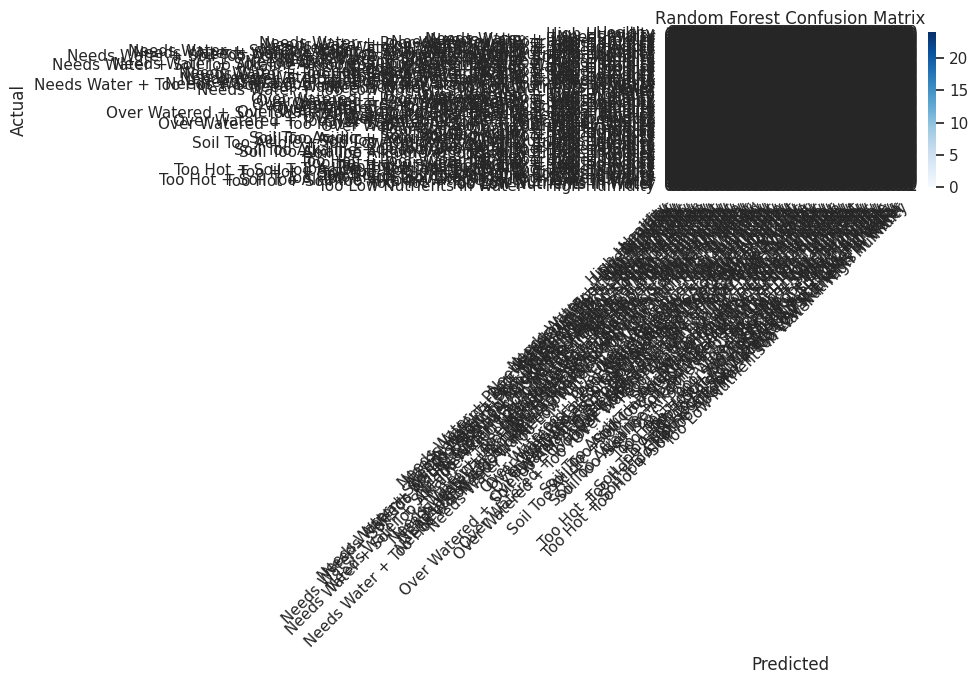


Gradient Boosting Accuracy: 0.6200
                                                                                precision    recall  f1-score   support

                                                                       Healthy       0.80      1.00      0.89        24
                                                                 High Humidity       1.00      0.75      0.86         4
                                                                  Low Humidity       0.67      1.00      0.80         6
                                                                   Needs Water       0.69      1.00      0.81        11
                                                   Needs Water + High Humidity       0.33      0.33      0.33         3
                                                    Needs Water + Low Humidity       0.50      0.33      0.40         3
                                              Needs Water + Poor Water Quality       1.00      0.60      0.75         5
   

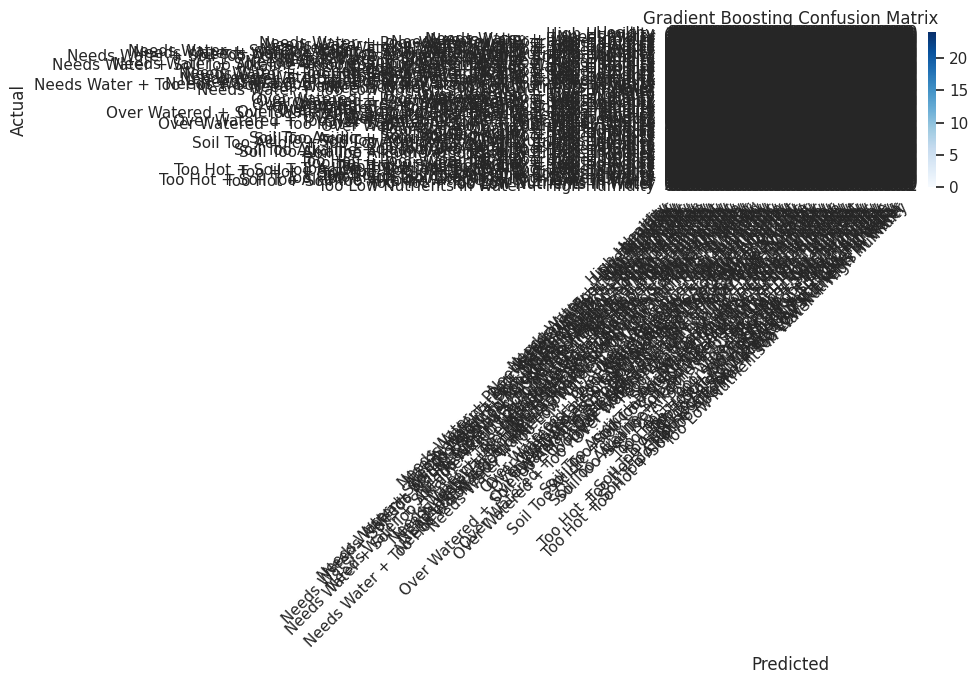


Voting Ensemble Accuracy: 0.9400
                                                                                precision    recall  f1-score   support

                                                                       Healthy       0.92      1.00      0.96        24
                                                                 High Humidity       1.00      0.75      0.86         4
                                                                  Low Humidity       0.86      1.00      0.92         6
                                                                   Needs Water       1.00      1.00      1.00        11
                                                   Needs Water + High Humidity       1.00      1.00      1.00         3
                                                    Needs Water + Low Humidity       1.00      1.00      1.00         3
                                              Needs Water + Poor Water Quality       1.00      1.00      1.00         5
     

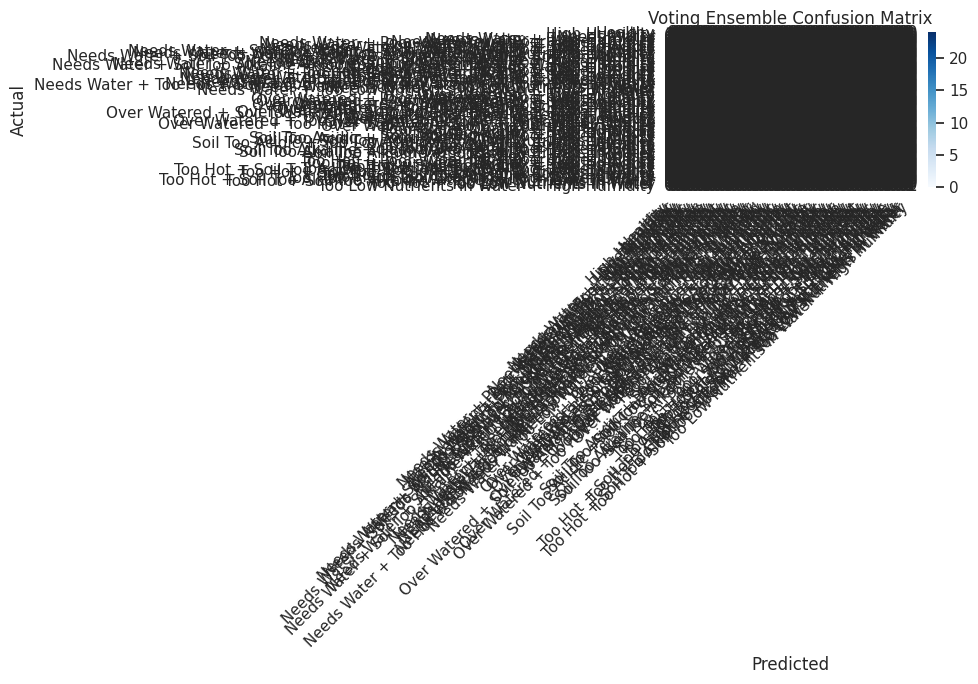

In [36]:
# BLOCK 7: Evaluation (UPDATED)
accuracy_results = {}
cv_results = {
    "Random Forest": rf_cv_score,
    "Gradient Boosting": gb_cv_score,
    ensemble_name: stacking_cv_score,
}

print("\n" + "="*60)
print("EVALUATING MODELS ON TEST SET")
print("="*60)

rf_eval = evaluate_model("Random Forest", best_rf_model, X_test, y_test, label_encoder)
gb_eval = evaluate_model("Gradient Boosting", best_gb_model, X_test, y_test, label_encoder)
ensemble_eval = evaluate_model(ensemble_name, stacking_pipeline, X_test, y_test, label_encoder)

accuracy_results[rf_eval["model"]] = rf_eval["accuracy"]
accuracy_results[gb_eval["model"]] = gb_eval["accuracy"]
accuracy_results[ensemble_eval["model"]] = ensemble_eval["accuracy"]

In [37]:
# BLOCK 8: Model Comparison Table
comparison_df = (
    pd.DataFrame(
        {
            "Model": list(accuracy_results.keys()),
            "Test Accuracy": list(accuracy_results.values()),
            "CV Accuracy": [cv_results[name] for name in accuracy_results.keys()],
        }
    )
    .sort_values(by="Test Accuracy", ascending=False)
    .reset_index(drop=True)
)

display(comparison_df.style.format({"Test Accuracy": "{:.4f}", "CV Accuracy": "{:.4f}"}))

,Model,Test Accuracy,CV Accuracy
0,Random Forest,0.9550,0.8787
1,Voting Ensemble,0.9400,0.8700
2,Gradient Boosting,0.6200,0.4788


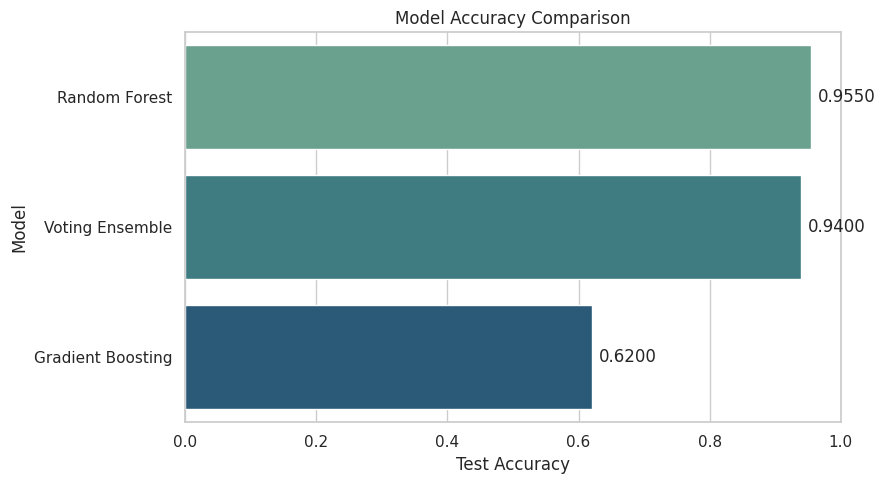

In [38]:
# BLOCK 9: Accuracy Visualization
plt.figure(figsize=(9, 5))
bar_ax = sns.barplot(data=comparison_df, x="Test Accuracy", y="Model", palette="crest")
for container in bar_ax.containers:
    bar_ax.bar_label(container, fmt="%.4f", padding=5)
plt.xlim(0, 1)
plt.title("Model Accuracy Comparison")
plt.xlabel("Test Accuracy")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

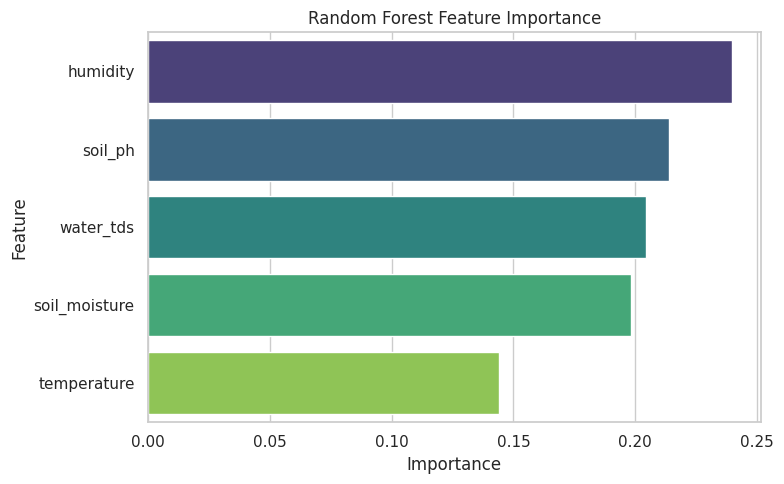

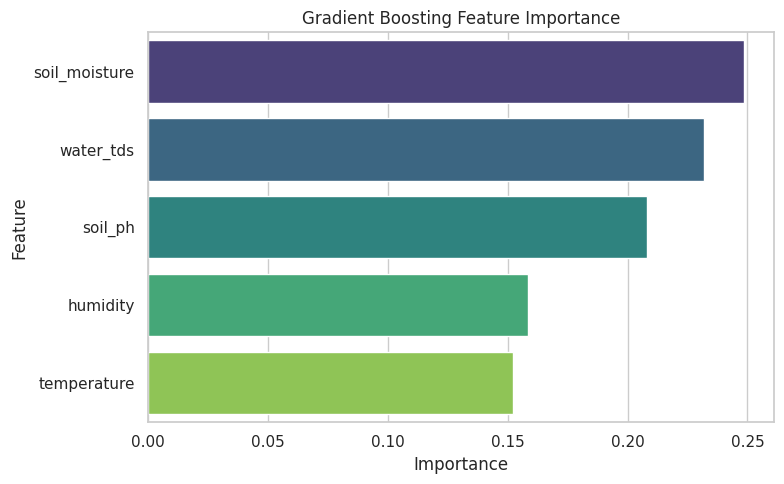

In [39]:
# BLOCK 10: Feature Importance (WITHOUT XGBoost)
plot_feature_importance(best_rf_model, "Random Forest")
plot_feature_importance(best_gb_model, "Gradient Boosting")

In [40]:
# BLOCK 11: Adaptive Logic and Edge Case Testing (WITHOUT XGBoost)
feature_bounds = X_train.agg(["min", "max", "median", "quantile"]).copy()

def build_edge_case_samples(reference_df):
    q10 = reference_df.quantile(0.10)
    q25 = reference_df.quantile(0.25)
    q50 = reference_df.quantile(0.50)
    q75 = reference_df.quantile(0.75)
    q90 = reference_df.quantile(0.90)

    samples = pd.DataFrame(
        [
            {
                "scenario": "High temperature + low moisture",
                "temperature": q90["temperature"],
                "soil_moisture": q10["soil_moisture"],
                "soil_ph": q50["soil_ph"],
                "water_tds": q50["water_tds"],
                "humidity": q25["humidity"],
            },
            {
                "scenario": "High TDS + low moisture",
                "temperature": q75["temperature"],
                "soil_moisture": q10["soil_moisture"],
                "soil_ph": q50["soil_ph"],
                "water_tds": q90["water_tds"],
                "humidity": q50["humidity"],
            },
            {
                "scenario": "Ideal conditions",
                "temperature": q50["temperature"],
                "soil_moisture": q75["soil_moisture"],
                "soil_ph": q50["soil_ph"],
                "water_tds": q25["water_tds"],
                "humidity": q75["humidity"],
            },
        ]
    )
    return samples


def decode_predictions(model, samples, encoder):
    encoded = model.predict(samples[feature_columns])
    return encoder.inverse_transform(encoded)


def test_edge_cases(samples_df, encoder, rf_model, gb_model, stack_model):
    result_df = samples_df.copy()
    result_df["RF Prediction"] = decode_predictions(rf_model, result_df, encoder)
    result_df["GB Prediction"] = decode_predictions(gb_model, result_df, encoder)
    result_df["Stacking Prediction"] = decode_predictions(stack_model, result_df, encoder)
    return result_df


edge_case_samples = build_edge_case_samples(X_train)
edge_case_results = test_edge_cases(edge_case_samples, label_encoder, best_rf_model, best_gb_model, stacking_pipeline)
display(edge_case_results)

,scenario,temperature,soil_moisture,soil_ph,water_tds,humidity,RF Prediction,GB Prediction,Stacking Prediction
0,High temperature + low moisture,37.785548,16.488030,6.819037,390.137890,43.969303,Needs Water + Too Hot,Needs Water + Too Hot,Needs Water + Too Hot
1,High TDS + low moisture,34.525000,16.488030,6.819037,643.028581,58.716849,Needs Water + Poor Water Quality,Needs Water + Poor Water Quality,Needs Water + Poor Water Quality
2,Ideal conditions,27.707361,62.197718,6.819037,222.523673,74.147274,Healthy,Healthy,Healthy


In [41]:
# BLOCK 12: Final Best Model Summary
best_model_row = comparison_df.iloc[0]
print("\n" + "="*60)
print("FINAL RESULTS")
print("="*60)
print(f"Best model: {best_model_row['Model']}")
print(f"Test accuracy: {best_model_row['Test Accuracy']:.4f}")
print(f"CV accuracy: {best_model_row['CV Accuracy']:.4f}")
print("="*60)


FINAL RESULTS
Best model: Random Forest
Test accuracy: 0.9550
CV accuracy: 0.8787
